# Thank-you packets and digital notes: descriptive evidence and limits

**Thadeus · September 26, 2026 · Group 11**

Integrated with current main on September 29, 2026.

We can compare recorded thank-you status with repeat giving. We cannot estimate the extra donations caused by thanking with these snapshot fields. The full interpretation, sources, pilot recommendation and parsing issue are in [the research memo](../docs/THANK-YOU-RESEARCH.md).

All calculations live in `evals/thank_you_audit.py`; this notebook presents its aggregate outputs. Rebuild with `python evals/thank_you_audit.py` after the standard donor-ID gate and label construction, or use `python evals/run_all.py` (step 18). This is an exploratory analysis, not a model selection step. This analysis does not fit or select a model.

## 1. Read the reproducible audit

The raw donation stream independently validates every citizen donor's repeat label and every single-first-month-row donor's amount, project and packet flag. The Projects file is parsed as literal TSV, with its row count and MD5 checked against the ICPSR manifest. The old CSV quote parser swallowed rows; do not interpret the old missing joins as absent public-use projects.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd() / 'evals').exists() else Path.cwd().parent
RESULTS = ROOT / 'evals/results/thank_you_audit'
def table(name):
    return pd.read_csv(RESULTS / (name + '.csv'))
print(json.dumps(json.loads((RESULTS / 'checks.json').read_text()), indent=2))

{
  "verified_single_first_month_rows": 2743076,
  "flag_mismatches": 0,
  "amount_mismatches": 0,
  "project_mismatches": 0,
  "all_citizen_repeat_labels_match": true,
  "projects_md5": "37e7bd5ac4af5b71545fc6538c5be3dd",
  "project_rows": 2149817,
  "citizen_donors": 2971755,
  "multirow_first_month_donors": 228679,
  "unmatched_citizen_donors": 0,
  "exactly_50_single_donors": 538562,
  "single_donors_45_to_under55": 557355,
  "funded_single_row_donors": 2451846,
  "funded_invalid_or_negative_duration": 0,
  "single_row_matched_donors": 2743076
}


## 2. Packets are associated with repeat giving

The flag means any donation in the first month eventually had a packet recorded. It does not say it was mailed in that month. The outcome is a positive gift in M+1 through M+12. “Future dollars” sums all positive gifts in that window. The citizen-donor raw gap is 7.52 percentage points; groups differ in size, eligibility, opt-in, funding and other characteristics. The table includes the other donor populations to show why we should not pool them.

In [2]:
display(table('01_packet_by_population'))
display(table('02_packet_by_split'))

,donor_type,packet,donors,repeat_rate,mean_future_dollars,packet_rate
0,citizen donor,False,2643712,0.127651,14.506946,0.0
1,citizen donor,True,328043,0.202812,67.524395,1.0
2,organization,False,1641,0.650213,55926.736015,0.0
3,organization,True,1588,0.704660,46432.925781,1.0
4,teacher,False,295795,0.368722,76.473343,0.0
5,teacher,True,6374,0.346564,107.522066,1.0


,split,packet,donors,repeat_rate,mean_future_dollars,packet_rate
0,holdout,False,708852,0.117079,16.179126,0.0
1,holdout,True,106119,0.185942,50.170197,1.0
2,train,False,1934860,0.131524,13.894329,0.0
3,train,True,221924,0.210878,75.822776,1.0


## 3. Compare supported groups, without calling this causal

Standardization weights each group's within-cell repeat rate by the pooled donor distribution. Cells are year × gift band × teacher referral × matching × campaign gift card, with at least 100 donors in each group. Report coverage; do not extrapolate unsupported cells. Final funded status is a post-gift selection, not a baseline control that makes the groups exchangeable.

Among single-row, funded, $50+ donors, the standardized packet gap is +3.65 points with 98.0% coverage. This remains an association. The older +12.5-point reweighting relies on very sparse small-gift packet groups; its arithmetic is reproducible but it is a different and poorly supported comparison.

In [3]:
display(table('10_standardized_associations'))

,analysis,source_donors,supported_donors,coverage,cells,repeat_no,repeat_yes,gap_pp
0,All citizens: packet,2971755,1934305,0.650897,194,0.150766,0.197036,4.626926
1,"Single first-month row, matched project: packet",2743076,1511556,0.551044,160,0.147552,0.179544,3.199202
2,"Single row, funded: packet",2451846,1365768,0.557037,159,0.131699,0.178979,4.727914
3,"Single row, funded, amount >=50: packet",938049,919340,0.980055,129,0.138621,0.175169,3.654769
4,"Single row, matched project: note",2743076,2676403,0.975694,233,0.170744,0.116374,-5.436965
5,"Single row, funded: note",2451846,72488,0.029565,3,0.042172,0.059404,1.723249


## 4. A digital note is different from a mailed packet

Project notes are written after funding. `MASKED BY ICPSR` indicates recorded text whose content is unavailable; blank is no recorded note, not proof of no thanks. Restricting to one donation in the first month aligns the donor with a single project.

99.90% of these donors to funded projects have a note recorded. The rare no-note donors are not a credible untreated comparison; only 3.0% of funded donors remain in adequately supported note-comparison cells. Note/packet combinations do not identify the separate effects of each communication. Impact letters also occur later in the project lifecycle.

In [4]:
display(table('06_note_and_funding'))
display(table('08_funded_packet_note_combinations'))
display(table('09_impact_and_funding'))

,status,note,donors,repeat_rate,mean_future_dollars,packet_rate
0,expired,False,278330,0.180272,13.577465,0.000000
1,funded,False,2557,0.157998,67.175025,0.425108
2,funded,True,2449289,0.118010,13.278304,0.116682
3,reallocated,False,12899,0.312582,29.357852,0.000000
4,reallocated,True,1,1.000000,25.000000,0.000000


,packet,note,donors,repeat_rate,mean_future_dollars,packet_rate
0,False,False,1470,0.124490,21.729456,0.0
1,False,True,2163502,0.110303,10.417215,0.0
2,True,False,1087,0.203312,128.633155,1.0
3,True,True,285787,0.176359,34.937691,1.0


,status,impact,donors,repeat_rate,mean_future_dollars,packet_rate
0,expired,False,278330,0.180272,13.577465,0.000000
1,funded,False,292981,0.092641,16.065630,0.114403
2,funded,True,2158865,0.121500,12.963870,0.117356
3,reallocated,False,12900,0.312636,29.357514,0.000000


## 5. The $50 comparison changes with the selected amounts

The historical policy supports $50 eligibility with opt-in, not deterministic receipt. Use one donation in the first month so the amount is not a sum across gifts. Exactly $50 accounts for 96.6% of the $45–54.99 window. Referral, matching and cohort composition differ across sides. The ratio of the two jumps is only a descriptive ratio; it is not a regression-discontinuity treatment effect. Its sign changes when the sample changes. No causal conclusion should be chosen because one selected comparison is positive.

,split,comparison,n_below,n_above,packet_below,packet_above,repeat_below,repeat_above,packet_gap_pp,repeat_gap_pp,descriptive_ratio
0,all,45–<50 vs 50–<55,12323,545032,0.085693,0.213261,0.164895,0.140355,12.756745,-2.453985,-0.192368
1,all,45–<50 vs >50–<55,12323,6470,0.085693,0.286090,0.164895,0.155796,20.039623,-0.909893,-0.045405
2,all,Non-multiple-of-5 whole dollars 41–49 vs 51–59,2888,3644,0.056094,0.227772,0.132618,0.152305,17.167750,1.968743,0.114677
3,train,45–<50 vs 50–<55,9000,335912,0.064778,0.204268,0.170000,0.146003,13.949001,-2.399748,-0.172037
4,train,45–<50 vs >50–<55,9000,4087,0.064778,0.284316,0.170000,0.165158,21.953835,-0.484218,-0.022056
5,train,Non-multiple-of-5 whole dollars 41–49 vs 51–59,1956,2449,0.053170,0.204165,0.145706,0.160474,15.099523,1.476814,0.097805
6,holdout,45–<50 vs 50–<55,3323,209120,0.142341,0.227707,0.151068,0.131283,8.536532,-1.978484,-0.231767
7,holdout,45–<50 vs >50–<55,3323,2383,0.142341,0.289131,0.151068,0.139740,14.679009,-1.132849,-0.077175
8,holdout,Non-multiple-of-5 whole dollars 41–49 vs 51–59,932,1195,0.062232,0.276151,0.105150,0.135565,21.391887,3.041464,0.142178


,side,donors,teacher_referred,matched,gift_card,mean_year
0,at_or_above,545032,0.559112,0.357419,0.108605,2015.226124
1,below,12323,0.339447,0.251968,0.132354,2013.439503


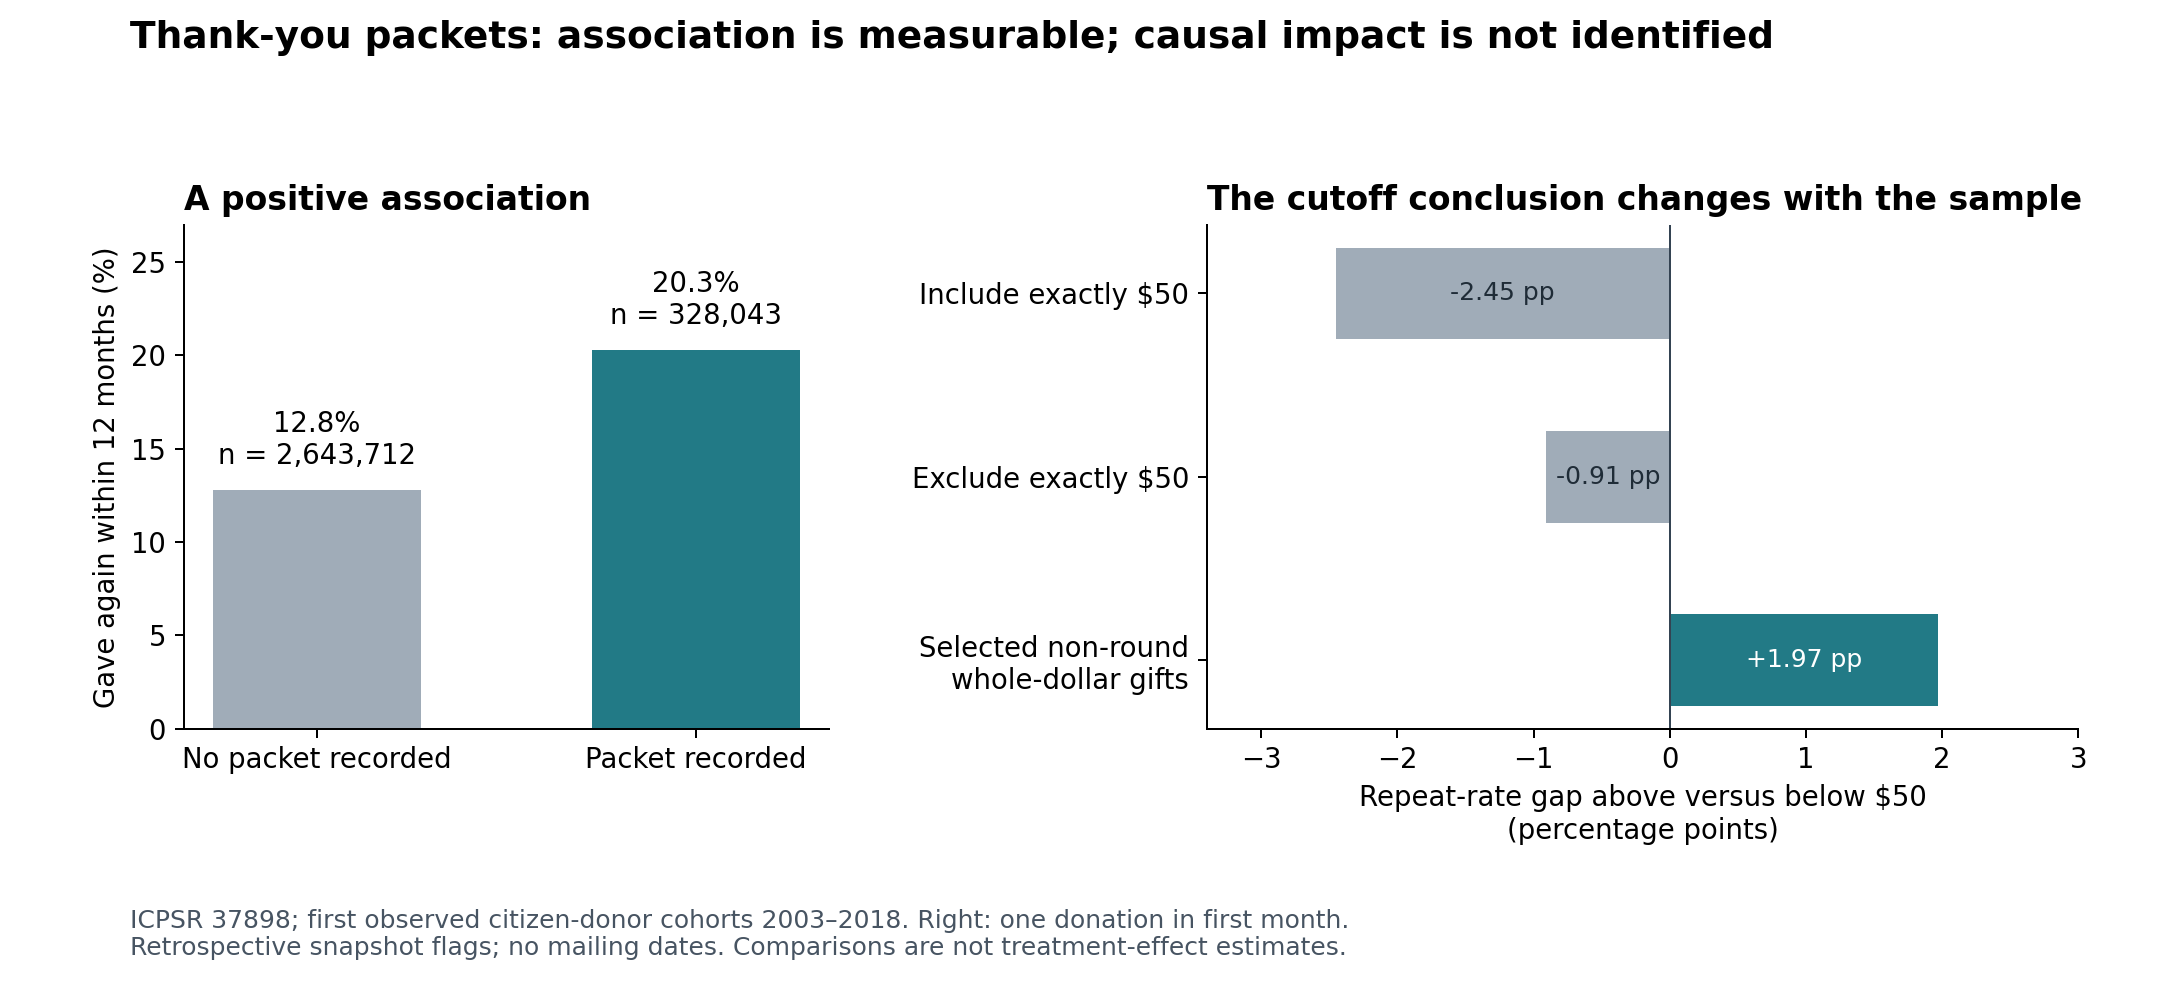

In [5]:
display(table('11_cutoff_sensitivity_NOT_CAUSAL'))
display(table('13_cutoff_composition'))
display(Image(filename=str(ROOT / 'docs/thank_you_audit.png')))

## 6. Some repeat giving definitely precedes the earliest possible thanks

For a funded project, take the first day of its posting month plus its documented days to completion. This is the earliest possible funding date. If the entire first-repeat month ends before that date, the repeat definitely came before funding. Digital notes are post-funding by definition; the documented packet workflow is post-funding too.

The conservative lower bounds are 653 packet-recorded repeaters and 4,834 repeaters with digital notes. These are not the total shares returning before receipt. For everyone else, temporal order remains unknown. Moving the outcome to months 4–12 does not repair missing exposure dates.

In [6]:
display(table('15_before_funding_lower_bound'))
display(table('14_return_timing'))

,group,donors,valid_duration,repeaters_with_valid_duration,definitely_repeated_before_funding,share_of_repeaters
0,All funded single-row donors,2451846,2451846,289445,4854,0.016770
1,Packet recorded yes,286874,286874,50622,653,0.012900
2,Digital note recorded,2449289,2449289,289041,4834,0.016724


,packet,donors,repeats,repeat_month_1,repeat_by_month_3,any_repeat_months_4_12
0,False,2643712,337473,71872,143733,0.090190
1,True,328043,66531,13034,27217,0.157175


## 7. Project recommendation

Keep one concise descriptive result and an appendix that demonstrates the identification limits. Do not claim that thanking works, does not work, or increases retention by the old +12% ratio. Retain the model's exclusion of these snapshot flags.

The shared Projects loader and frozen evaluation were corrected in PR #2, merged September 27. This audit now uses the shared loader; see [the parser-fix audit](../docs/PROJECT-PARSER-FIX.md) for the changed headline results. For a future pilot, randomize additional thanks against standard stewardship, log assignment/send/receipt and gift timestamps, and evaluate repeat rate and net incremental giving from the assignment date.

**Primary sources:** [DonorsChoose's 2015 policy description](https://blog.donorschoose.org/articles/power-of-student-thank-you-notes), [current delivery guidance](https://help.donorschoose.org/hc/en-us/articles/201937136-Donors-waiting-for-Student-Thank-Yous), [Althoff and Leskovec (2015)](https://arxiv.org/html/1503.02729), and the local ICPSR dictionary/codebooks listed in the memo.

**AI disclosure:** Codex assisted the audit and write-up. All local reported statistics come from the supplied script; raw-data reconciliation, checksum/joins and 29 tests passed, including hand-worked standardization and missing-comparison checks. The group owns the final interpretation.